# Regressió ML amb Sklearn

En cada secció, procura entendre molt bé què estàs fent: què fa el codi, per què fem això? Si en algun punt no ho tens clar, no segueixis! Para't a pensar-hi i pregunta si és necessari.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

from sklearn.linear_model import LinearRegression

## Càrrega de dades

Aquestes dades han d'estar netes i preparades per aplicar ML.

In [2]:
df = pd.read_csv('house_pricing_parcial.csv')
df.head()
df.shape

(992, 35)

### Split column

Separem dades de leaderboard (prediccions per la plataforma) i les que farem servir per fer el procés de ML.

In [3]:
# Separem dades de leaderboard
#leaderboard_df = df[df['Split'] == 'leaderboard'].copy()
#df = df[df['Split'] == 'labeled']

# 1. Separar y aislar el leaderboard (datos sin SalePrice conocidos)
leaderboard_df = df[df['Split'] == 'leaderboard'].copy()

# 2. Conservar todo lo que esté etiquetado (tanto train como validation)
df = df[df['Split'].isin(['train', 'validation'])].copy()

# Comprobamos los tamaños inmediatamente en la misma celda
print("Filas en el set de entrenamiento/validación (df):", df.shape[0])
print("Filas en el set de competición (leaderboard_df):", leaderboard_df.shape[0])

Filas en el set de entrenamiento/validación (df): 794
Filas en el set de competición (leaderboard_df): 198


## Pipeline de Feature Engineering

Defineix els passos de preprocessament per als models que ho necessiten.

In [4]:
onehot_pipeline = Pipeline([
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore')),
])

In [5]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# 1. Separar los nombres de las columnas según su tipo de dato
# Columnas categóricas (texto)
onehot_features = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
if 'Split' in onehot_features:
    onehot_features.remove('Split')

# Columnas numéricas (enteros y decimales)
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'SalePrice' in numeric_features:
    numeric_features.remove('SalePrice')

# 2. Definir las sub-pipelines de procesamiento independientes
onehot_pipeline = Pipeline([
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')) # ¡Aquí tratamos los nulos numéricos de forma segura!
])

# 3. Unificar ambos flujos en el ColumnTransformer principal
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_features),
        ('cat', onehot_pipeline, onehot_features)
    ],
    remainder='drop' # Cambiamos a 'drop' porque ya cubrimos explícitamente el 100% de las columnas
)

## Entrenament / Test

- Podem emular dades no vistes dividint les nostres dades en conjunts d'**entrenament** i de **test**.
    - Usem el conjunt d'entrenament per ajustar (entrenar) el nostre model.
    - Usem el conjunt de test per avaluar el rendiment del model amb dades no vistes.

- Les mides de test habituals són del 10-30% de les dades inicials.
    - Els conjunts de dades grans poden requerir un percentatge menor (p. ex., 10-20%).
    - Els conjunts de dades petits poden necessitar un conjunt de test més gran per garantir que sigui representatiu (p. ex., 30-40%).

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
# 1. Crear la variable X amb les característiques predictores
# (eliminem 'SalePrice' i també 'Split' perquè no confongui el model)
X = df.drop(['SalePrice', 'Split'], axis=1)

# 2. Separar l'objectiu en la variable `y`
y = df['SalePrice']

# 3. Divisió Entrenament / Test (20% de dades per a test, equivalent a test_size=0.2)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,  # Mantinguem el 20% de l'exemple de tips
    shuffle=True,
    random_state=42
)

# Comprovació de les mides resultants
print(f"Mida de X_train: {X_train.shape} | Mida de y_train: {y_train.shape}")
print(f"Mida de X_test: {X_test.shape} | Mida de y_test: {y_test.shape}")

Mida de X_train: (635, 33) | Mida de y_train: (635,)
Mida de X_test: (159, 33) | Mida de y_test: (159,)


## Entrenament del model

### Baseline

- Entrena i avalua el rendiment d'un model de referència (baseline).
- Proporciona una mesura inicial del rendiment.
- Qualsevol model que desenvolupis hauria de superar aquesta línia base simple.

In [8]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.dummy import DummyRegressor

# 1. El baseline predirà sempre el valor mitjà de la columna target (SalePrice)
bl = DummyRegressor(strategy='mean')

# 2. Entrenar el model de referència amb les dades de les cases
bl.fit(X_train, y_train)

# 3. Predir el conjunt d'entrenament
y_pred_train = bl.predict(X_train)

# 4. Calcular els errors (MAE i RMSE) per al nostre conjunt d'habitatges
mae_train_bl = mean_absolute_error(y_train, y_pred_train)
rmse_train_bl = root_mean_squared_error(y_train, y_pred_train)

# 5. Mostrar els resultats per pantalla ben formats
print(f'Train Baseline MAE:  {mae_train_bl:.1f} $')
print(f'Train Baseline RMSE: {rmse_train_bl:.1f} $')

Train Baseline MAE:  40570.4 $
Train Baseline RMSE: 55037.1 $


### Regressió lineal

- Cada vegada que entrenem la regressió lineal,
- el model aprèn els coeficients $w_i$ (en funció de les característiques $x_i$):

    $\hat{y} = w_0 + w_1 \cdot x_1 + w_2 \cdot x_2 + \text{...} + w_n \cdot x_n$


- de manera que les prediccions $\hat{y}$ minimitzin $MSE(y, \hat{y})$.

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# 1. Definir la Pipeline conectando el nuevo preprocesador con el regresor lineal
lr = Pipeline([
    ('preprocessor', preprocessor),
    ('lr', LinearRegression(n_jobs=-1))
])

# 2. Entrenar el modelo (Ahora se ejecutará sin ningún error de conversión de texto)
lr.fit(X_train, y_train)

# 3. Predecir los precios para el conjunto de entrenamiento
y_pred_train_lr = lr.predict(X_train)

# 4. Calcular los errores de predicción
mae_train_lr = mean_absolute_error(y_train, y_pred_train_lr)
rmse_train_lr = root_mean_squared_error(y_train, y_pred_train_lr)

# 5. Mostrar los resultados
print(f'Train Linear Regression MAE:  {mae_train_lr:.1f} $')
print(f'Train Linear Regression RMSE: {rmse_train_lr:.1f} $')

Train Linear Regression MAE:  12290.2 $
Train Linear Regression RMSE: 16996.5 $


## Test

Els models ja han estat entrenats amb `X_train`. Vegem com funcionen amb dades que mai han vist (`X_test`).

=== METRIQUES DE TEST ===
Baseline (Model Dummy) -> MAE: 41452.2 $ | RMSE: 54580.5 $
Regressió Lineal       -> MAE: 13119.5 $ | RMSE: 17269.0 $


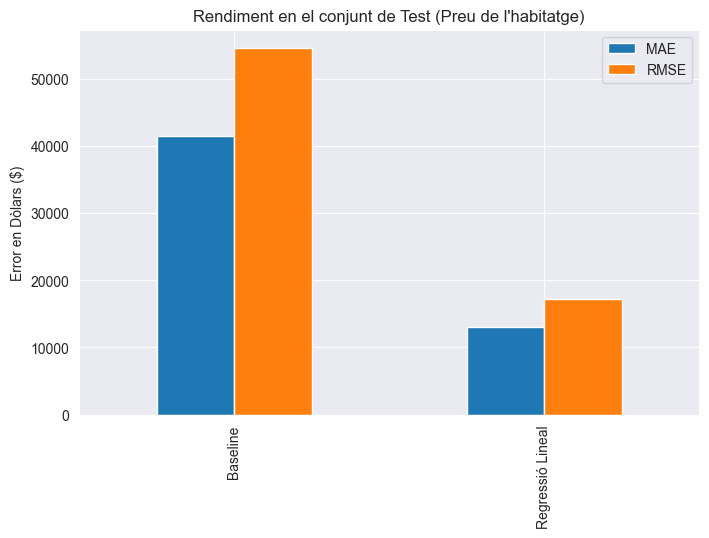

In [10]:
# 1. Predir les dades de test (cases que el model mai ha vist)
y_test_bl = bl.predict(X_test)
y_test_lr = lr.predict(X_test)

# 2. Calcular el MAE (Error Absolut Mitjà) de test
mae_test_bl = mean_absolute_error(y_test, y_test_bl)
mae_test_lr = mean_absolute_error(y_test, y_test_lr)

# 3. Calcular el RMSE (Error Quadràtic Mig de l'Arrel) de test
rmse_test_bl = root_mean_squared_error(y_test, y_test_bl)
rmse_test_lr = root_mean_squared_error(y_test, y_test_lr)

# 4. Crear un DataFrame per a recopilar i comparar els resultats
results_df = pd.DataFrame(
    {
        'MAE': [mae_test_bl, mae_test_lr],
        'RMSE': [rmse_test_bl, rmse_test_lr]
    },
    index=['Baseline', 'Regressió Lineal'],
)

# 5. Visualitzar els resultats en un gràfic de barres
results_df.plot(
    kind='bar',
    title="Rendiment en el conjunt de Test (Preu de l'habitatge)",
    ylabel='Error en Dòlars ($)',
    figsize=(8, 5)
);

# 6. Mostrar els valors numèrics exactes per pantalla
print("=== METRIQUES DE TEST ===")
print(f"Baseline (Model Dummy) -> MAE: {mae_test_bl:.1f} $ | RMSE: {rmse_test_bl:.1f} $")
print(f"Regressió Lineal       -> MAE: {mae_test_lr:.1f} $ | RMSE: {rmse_test_lr:.1f} $")

# Exercicis Extra

Abans de començar aquests exercicis, assegura't d'haver completat el notebook introductori de ML.

El que farem a continuació no se sol fer en un procés de ML.

Farem aquests exercicis per tal que desenvolupeu una comprensió més profunda sobre els temes tractats.

## Loteria

Quan fem una sola divisió aleatòria de train/test, el resultat depèn de la sort. Amb unes dades, el model sembla excel·lent; amb altres, sembla mediocre. Aquí ho comprovaràs empíricament.

Instruccions pas a pas:
- Escriu un bucle que repeteixi 10 vegades l'operació `train_test_split` canviant el paràmetre `random_state` (del 0 al 9, per exemple).
- En cada iteració: entrena un `LinearRegression`, calcula les mètriques sobre el test, i guarda els resultats en una variable.
- Mostra un gràfic amb els resultats obtinguts.

## Mida de test

Hi ha una tensió fonamental entre dedicar dades a entrenar el model i dedicar dades a avaluar-lo. Explorarem aquest equilibri visualment.

Instruccions pas a pas:
- Defineix una llista de mides de test: `[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]`.
- Per a cada mida, fes la divisió train/test, entrena el model, i guarda l'error MAE tant de train com de test.
- Fes un gràfic de línies on l'eix X sigui `test_size` i l'eix Y sigui el MAE, amb dues línies (train i test). Així veiem com canvia l'error en funció de si tenim més o menys dades d'entrenament i test.


## Mètriques

Les mètriques no són màgia. Pots calcular-les tu mateix amb `numpy` o `pandas` i el resultat ha de ser idèntic al de `sklearn`.

Instruccions pas a pas:
- Fes prediccions sobre el test. Imprimeix els valors reals i els predits.
- Calcula MAE a mà: la mitjana dels errors absoluts de cada exemple.
- Calcula RMSE a mà: arrel de la mitjana dels errors al quadrat.
- Verifica que coincideix amb les mètriques de `sklearn`.


## Variables per eliminació

Quin impacte té cada variable sobre el model? Ho podem mesurar eliminant variables una a una i observant com canvia l'error.

Instruccions pas a pas:
- Entrena el model complet (totes les variables) i guarda el MAE de referència.
- Escriu un bucle: en cada iteració, elimina una sola variable, reentrena, i registra el nou MAE.
- Fes un gràfic de barres horitzontal: l'eix Y és el nom de la variable eliminada, l'eix X és la diferència de MAE respecte al model complet.
